In [1]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Gráficos
import matplotlib.pyplot as plt

# Preprocesado y modelo
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from numpy import linalg as LA

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.DataFrame(
    np.array([
        [5.1, 3.5, 1.4, .2, 'Setosa'],
        [4.9, 3, 1.4, .2, 'Setosa'],
        [4.7, 3.2, 1.3, .2, 'Setosa'],
        [4.6, 3.1, 1.5, .2, 'Setosa'],
        [5, 3.6, 1.4, .2, 'Setosa'],
        [5.4, 3.9, 1.7, .4, 'Setosa'],
        [4.6, 3.4, 1.4, .3, 'Setosa'],
        [5, 3.4, 1.5, .2, 'Setosa'],
        [4.4, 2.9, 1.4, .2, 'Setosa'],
        [4.9, 3.1, 1.5, .1, 'Setosa'],
        [5.4, 3.7, 1.5, .2, 'Setosa'],
        [4.8, 3.4, 1.6, .2, 'Setosa'],
        [4.8, 3, 1.4, .1, 'Setosa'],
        [4.3, 3, 1.1, .1, 'Setosa'],
        [5.8, 4, 1.2, .2, 'Setosa'],
        [5.7, 4.4, 1.5, .4, 'Setosa'],
        [5.4, 3.9, 1.3, .4, 'Setosa'],
        [5.1, 3.5, 1.4, .3, 'Setosa'],
        [5.7, 3.8, 1.7, .3, 'Setosa'],
        [5.1, 3.8, 1.5, .3, 'Setosa'],
        [5.4, 3.4, 1.7, .2, 'Setosa'],
        [5.1, 3.7, 1.5, .4, 'Setosa'],
        [4.6, 3.6, 1, .2, 'Setosa'],
        [5.1, 3.3, 1.7, .5, 'Setosa'],
        [4.8, 3.4, 1.9, .2, 'Setosa'],
        [5, 3, 1.6, .2, 'Setosa'],
        [5, 3.4, 1.6, .4, 'Setosa'],
        [5.2, 3.5, 1.5, .2, 'Setosa'],
        [5.2, 3.4, 1.4, .2, 'Setosa'],
        [4.7, 3.2, 1.6, .2, 'Setosa'],
        [4.8, 3.1, 1.6, .2, 'Setosa'],
        [5.4, 3.4, 1.5, .4, 'Setosa'],
        [5.2, 4.1, 1.5, .1, 'Setosa'],
        [5.5, 4.2, 1.4, .2, 'Setosa'],
        [4.9, 3.1, 1.5, .2, 'Setosa'],
        [5, 3.2, 1.2, .2, 'Setosa'],
        [5.5, 3.5, 1.3, .2, 'Setosa'],
        [4.9, 3.6, 1.4, .1, 'Setosa'],
        [4.4, 3, 1.3, .2, 'Setosa'],
        [5.1, 3.4, 1.5, .2, 'Setosa'],
        [5, 3.5, 1.3, .3, 'Setosa'],
        [4.5, 2.3, 1.3, .3, 'Setosa'],
        [4.4, 3.2, 1.3, .2, 'Setosa'],
        [5, 3.5, 1.6, .6, 'Setosa'],
        [5.1, 3.8, 1.9, .4, 'Setosa'],
        [4.8, 3, 1.4, .3, 'Setosa'],
        [5.1, 3.8, 1.6, .2, 'Setosa'],
        [4.6, 3.2, 1.4, .2, 'Setosa'],
        [5.3, 3.7, 1.5, .2, 'Setosa'],
        [5, 3.3, 1.4, .2, 'Setosa'],
        [7, 3.2, 4.7, 1.4, 'Versicolor'],
        [6.4, 3.2, 4.5, 1.5, 'Versicolor'],
        [6.9, 3.1, 4.9, 1.5, 'Versicolor'],
        [5.5, 2.3, 4, 1.3, 'Versicolor'],
        [6.5, 2.8, 4.6, 1.5, 'Versicolor'],
        [5.7, 2.8, 4.5, 1.3, 'Versicolor'],
        [6.3, 3.3, 4.7, 1.6, 'Versicolor'],
        [4.9, 2.4, 3.3, 1, 'Versicolor'],
        [6.6, 2.9, 4.6, 1.3, 'Versicolor'],
        [5.2, 2.7, 3.9, 1.4, 'Versicolor'],
        [5, 2, 3.5, 1, 'Versicolor'],
        [5.9, 3, 4.2, 1.5, 'Versicolor'],
        [6, 2.2, 4, 1, 'Versicolor'],
        [6.1, 2.9, 4.7, 1.4, 'Versicolor'],
        [5.6, 2.9, 3.6, 1.3, 'Versicolor'],
        [6.7, 3.1, 4.4, 1.4, 'Versicolor'],
        [5.6, 3, 4.5, 1.5, 'Versicolor'],
        [5.8, 2.7, 4.1, 1, 'Versicolor'],
        [6.2, 2.2, 4.5, 1.5, 'Versicolor'],
        [5.6, 2.5, 3.9, 1.1, 'Versicolor'],
        [5.9, 3.2, 4.8, 1.8, 'Versicolor'],
        [6.1, 2.8, 4, 1.3, 'Versicolor'],
        [6.3, 2.5, 4.9, 1.5, 'Versicolor'],
        [6.1, 2.8, 4.7, 1.2, 'Versicolor'],
        [6.4, 2.9, 4.3, 1.3, 'Versicolor'],
        [6.6, 3, 4.4, 1.4, 'Versicolor'],
        [6.8, 2.8, 4.8, 1.4, 'Versicolor'],
        [6.7, 3, 5, 1.7, 'Versicolor'],
        [6, 2.9, 4.5, 1.5, 'Versicolor'],
        [5.7, 2.6, 3.5, 1, 'Versicolor'],
        [5.5, 2.4, 3.8, 1.1, 'Versicolor'],
        [5.5, 2.4, 3.7, 1, 'Versicolor'],
        [5.8, 2.7, 3.9, 1.2, 'Versicolor'],
        [6, 2.7, 5.1, 1.6, 'Versicolor'],
        [5.4, 3, 4.5, 1.5, 'Versicolor'],
        [6, 3.4, 4.5, 1.6, 'Versicolor'],
        [6.7, 3.1, 4.7, 1.5, 'Versicolor'],
        [6.3, 2.3, 4.4, 1.3, 'Versicolor'],
        [5.6, 3, 4.1, 1.3, 'Versicolor'],
        [5.5, 2.5, 4, 1.3, 'Versicolor'],
        [5.5, 2.6, 4.4, 1.2, 'Versicolor'],
        [6.1, 3, 4.6, 1.4, 'Versicolor'],
        [5.8, 2.6, 4, 1.2, 'Versicolor'],
        [5, 2.3, 3.3, 1, 'Versicolor'],
        [5.6, 2.7, 4.2, 1.3, 'Versicolor'],
        [5.7, 3, 4.2, 1.2, 'Versicolor'],
        [5.7, 2.9, 4.2, 1.3, 'Versicolor'],
        [6.2, 2.9, 4.3, 1.3, 'Versicolor'],
        [5.1, 2.5, 3, 1.1, 'Versicolor'],
        [5.7, 2.8, 4.1, 1.3, 'Versicolor'],
        [6.3, 3.3, 6, 2.5, 'Virginica'],
        [5.8, 2.7, 5.1, 1.9, 'Virginica'],
        [7.1, 3, 5.9, 2.1, 'Virginica'],
        [6.3, 2.9, 5.6, 1.8, 'Virginica'],
        [6.5, 3, 5.8, 2.2, 'Virginica'],
        [7.6, 3, 6.6, 2.1, 'Virginica'],
        [4.9, 2.5, 4.5, 1.7, 'Virginica'],
        [7.3, 2.9, 6.3, 1.8, 'Virginica'],
        [6.7, 2.5, 5.8, 1.8, 'Virginica'],
        [7.2, 3.6, 6.1, 2.5, 'Virginica'],
        [6.5, 3.2, 5.1, 2, 'Virginica'],
        [6.4, 2.7, 5.3, 1.9, 'Virginica'],
        [6.8, 3, 5.5, 2.1, 'Virginica'],
        [5.7, 2.5, 5, 2, 'Virginica'],
        [5.8, 2.8, 5.1, 2.4, 'Virginica'],
        [6.4, 3.2, 5.3, 2.3, 'Virginica'],
        [6.5, 3, 5.5, 1.8, 'Virginica'],
        [7.7, 3.8, 6.7, 2.2, 'Virginica'],
        [7.7, 2.6, 6.9, 2.3, 'Virginica'],
        [6, 2.2, 5, 1.5, 'Virginica'],
        [6.9, 3.2, 5.7, 2.3, 'Virginica'],
        [5.6, 2.8, 4.9, 2, 'Virginica'],
        [7.7, 2.8, 6.7, 2, 'Virginica'],
        [6.3, 2.7, 4.9, 1.8, 'Virginica'],
        [6.7, 3.3, 5.7, 2.1, 'Virginica'],
        [7.2, 3.2, 6, 1.8, 'Virginica'],
        [6.2, 2.8, 4.8, 1.8, 'Virginica'],
        [6.1, 3, 4.9, 1.8, 'Virginica'],
        [6.4, 2.8, 5.6, 2.1, 'Virginica'],
        [7.2, 3, 5.8, 1.6, 'Virginica'],
        [7.4, 2.8, 6.1, 1.9, 'Virginica'],
        [7.9, 3.8, 6.4, 2, 'Virginica'],
        [6.4, 2.8, 5.6, 2.2, 'Virginica'],
        [6.3, 2.8, 5.1, 1.5, 'Virginica'],
        [6.1, 2.6, 5.6, 1.4, 'Virginica'],
        [7.7, 3, 6.1, 2.3, 'Virginica'],
        [6.3, 3.4, 5.6, 2.4, 'Virginica'],
        [6.4, 3.1, 5.5, 1.8, 'Virginica'],
        [6, 3, 4.8, 1.8, 'Virginica'],
        [6.9, 3.1, 5.4, 2.1, 'Virginica'],
        [6.7, 3.1, 5.6, 2.4, 'Virginica'],
        [6.9, 3.1, 5.1, 2.3, 'Virginica'],
        [5.8, 2.7, 5.1, 1.9, 'Virginica'],
        [6.8, 3.2, 5.9, 2.3, 'Virginica'],
        [6.7, 3.3, 5.7, 2.5, 'Virginica'],
        [6.7, 3, 5.2, 2.3, 'Virginica'],
        [6.3, 2.5, 5, 1.9, 'Virginica'],
        [6.5, 3, 5.2, 2, 'Virginica'],
        [6.2, 3.4, 5.4, 2.3, 'Virginica'],
        [5.9, 3, 5.1, 1.8, 'Virginica']
    ]),
    columns=['sepal.length', 'sepal.width', 'petal.length', 'petal.width', 'variety']
)

df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3,5.2,2.3,Virginica
146,6.3,2.5,5,1.9,Virginica
147,6.5,3,5.2,2,Virginica
148,6.2,3.4,5.4,2.3,Virginica


In [5]:
# Determinar el número de renglones de la base de datos
index = df.index
renglones = len(index)
renglones

150

In [6]:
# Estandarización de las variables
df2 = StandardScaler().fit_transform(df.iloc[:,0:4])
df2

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [7]:
# Calcular la matriz de correlaciones para la matriz transformada
A = (1/renglones) * np.dot(df2.T, df2)
A

array([[ 1.        , -0.11756978,  0.87175378,  0.81794113],
       [-0.11756978,  1.        , -0.4284401 , -0.36612593],
       [ 0.87175378, -0.4284401 ,  1.        ,  0.96286543],
       [ 0.81794113, -0.36612593,  0.96286543,  1.        ]])

In [11]:
# Entrenamiento del modelo PCA con escalado de los datos
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(df.iloc[:,0:4])

# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']

print('Eigenvalores:')
results = LA.eigvals(A)
print(results)

Eigenvalores:
[2.91849782 0.91403047 0.14675688 0.02071484]


In [12]:
# Porcentaje de la varianza explicada por cada nuevo componente
print("Porcentaje de varianza explicada por componente")
print(modelo_pca.explained_variance_ratio_)

Porcentaje de varianza explicada por componente
[0.72962445 0.22850762 0.03668922 0.00517871]


In [14]:
# Cálculo de eigenvectores
print('Eigenvectores (por renglón):')
pd.DataFrame(
    data = modelo_pca.components_,
    columns = df.columns[0:4],
    index = ['PC1', 'PC2', 'PC3', 'PC4']
)

Eigenvectores (por renglón):


,sepal.length,sepal.width,petal.length,petal.width
PC1,0.521066,-0.269347,0.580413,0.564857
PC2,0.377418,0.923296,0.024492,0.066942
PC3,0.719566,-0.244382,-0.142126,-0.634273
PC4,-0.261286,0.123510,0.801449,-0.523597


In [16]:
# Proyecciones de los componentes
proyecciones = np.dot(modelo_pca.components_, df2.T)
proyecciones = pd.DataFrame(
    proyecciones,
    index = ['PC1', 'PC2', 'PC3', 'PC4']
)
proyecciones = proyecciones.transpose().set_index(df.index)
proyecciones

,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
...,...,...,...,...
145,1.870503,0.386966,-0.256274,-0.389257
146,1.564580,-0.896687,0.026371,-0.220192
147,1.521170,0.269069,-0.180178,-0.119171
148,1.372788,1.011254,-0.933395,-0.026129


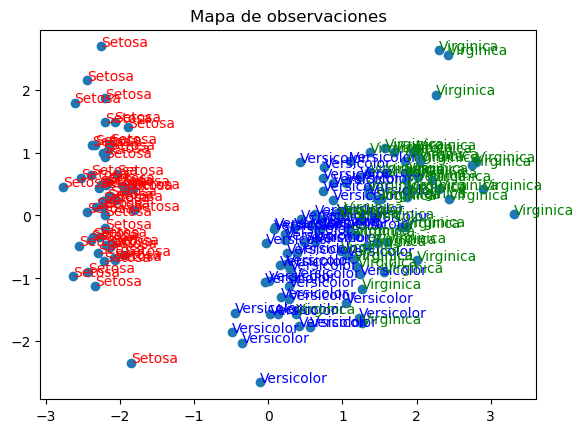

In [19]:
# Mapa de observaciones
x = proyecciones.iloc[:,0]
y = proyecciones.iloc[:,1]

z = df.index
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones")
ax.scatter(x, y)

colores = {
    'Setosa': 'red',
    'Versicolor': 'blue',
    'Virginica': 'green'
}

for i, txt in enumerate(df['variety']):
    ax.annotate(
        txt,
        (x[i], y[i]),
        color=colores[txt]
    )

In [24]:
componentes_2 = pd.DataFrame(
    data = modelo_pca.components_,
    columns = df.columns[0:4],
    index = ['PC1', 'PC2', 'PC3', 'PC4']
)

componentes_2 = componentes_2.iloc[0:2, :]
componentes_2=componentes_2.T
componentes_2

,PC1,PC2
sepal.length,0.521066,0.377418
sepal.width,-0.269347,0.923296
petal.length,0.580413,0.024492
petal.width,0.564857,0.066942


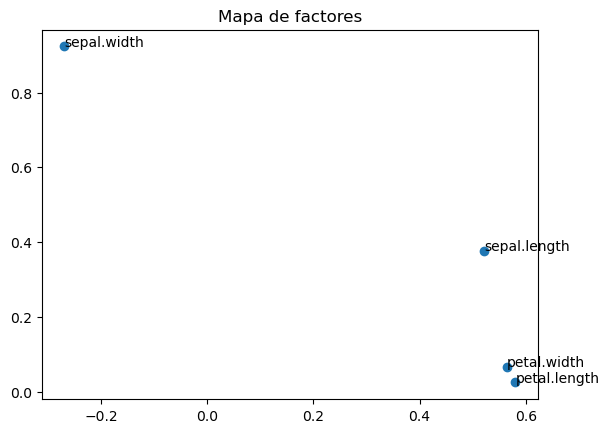

In [25]:
# Mapa de factores
x = componentes_2.iloc[:,0]
y = componentes_2.iloc[:,1]
z = componentes_2.index

x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de factores")
ax.scatter(x, y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))